In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import keras_tuner
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten 
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU

E0000 00:00:1779709574.003535  237119 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1779709574.003574  237119 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1779709574.003578  237119 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1779709574.003581  237119 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1779709574.003582  237119 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [2]:
def build_model(input_lenght=4, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [3]:
iris = load_iris()

X = iris.data       
y = iris.target     

In [4]:
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [5]:
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [7]:
EPOCHS = 100
BATCH_SIZE = 32
Loss1 = []
Accuracy1 = []
for _ in range(40):
    model = build_model(depth=5, n_class=2)
    fit = model.fit(X_train_sv, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_sv, y_test_sv),
                    verbose=False,
                    shuffle=True)    
    loss1 = np.array(fit.history['loss'])
    accuracy1 = np.array(fit.history['accuracy'])
    Loss1.append(loss1)
    Accuracy1.append(accuracy1)

Loss1 = np.array(Loss1)         
Accuracy1 = np.array(Accuracy1) 

loss_mean1 = np.mean(Loss1, axis=0)
loss_std1 = np.std(Loss1, axis=0)

acc_mean1 = np.mean(Accuracy1, axis=0)
acc_std1 = np.std(Accuracy1, axis=0)

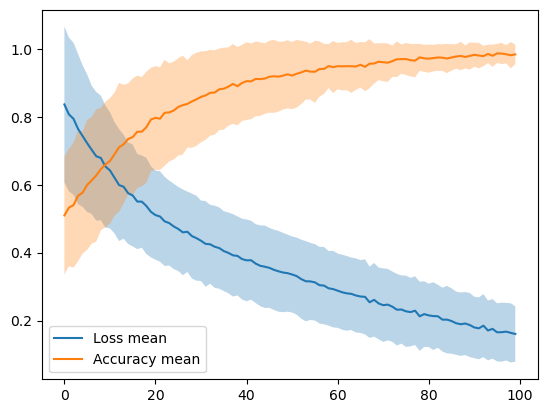

In [8]:

epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, acc_mean1, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)

plt.legend()
plt.show()

In [9]:
def compute_fisher(model, X, y):

    fisher = np.zeros((4, 4))

    dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(1)

    for x_batch, y_batch in dataset:

        x_batch = tf.cast(x_batch, tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(x_batch)   

            preds = model(x_batch, training=False)

            loss = tf.keras.losses.sparse_categorical_crossentropy(
                y_batch,
                preds
            )

        grads = tape.gradient(loss, x_batch)

        if grads is None:
            continue  # safety check

        g = tf.reshape(grads, (4,)).numpy()

        fisher += np.outer(g, g)

    fisher /= len(X)

    return fisher

In [10]:
F = compute_fisher(model, X_train_sv, y_train_sv)

In [11]:
F

array([[ 0.10995159, -0.06820126, -0.09300218, -0.10450355],
       [-0.06820126,  0.16175566, -0.06697295,  0.08416498],
       [-0.09300218, -0.06697295,  0.2164015 ,  0.08318034],
       [-0.10450355,  0.08416498,  0.08318034,  0.13201193]])

## Component analysis

In [12]:
t = F.trace()

eigvals, eigvecs = np.linalg.eigh(F)

for i in range(len(eigvals)):
    M = np.sort(eigvals)[::-1][i]
    M/t
    print(f'Information in eigenvalue {i}: {M/t:.2f}')

Information in eigenvalue 0: 0.57
Information in eigenvalue 1: 0.40
Information in eigenvalue 2: 0.03
Information in eigenvalue 3: 0.00


## PCA with Fisher matrix

Taking only the 2 combinations of parameters that contain the 96% of the information

In [13]:
U, S, VT = np.linalg.svd(F)

idx = np.argsort(eigvals)[::-1]

U = U[:, idx]

U2 = U[:, :2]

X_train_fisher2 = X_train_sv @ U2
X_test_fisher2 = X_test_sv @ U2

In [14]:
def build_model2(input_lenght=2, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [16]:
EPOCHS = 100
BATCH_SIZE = 32
Loss2 = []
Accuracy2 = []
for _ in range(40):
    model = build_model2(depth=5, n_class=2)
    fit = model.fit(X_train_fisher2, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_fisher2, y_test_sv),
                    verbose=False,
                    shuffle=True)        
    loss = np.array(fit.history['loss'])
    accuracy  = np.array(fit.history['accuracy'])
    Loss2.append(loss)
    Accuracy2.append(accuracy)

In [17]:
Loss2 = np.array(Loss2)         
Accuracy2 = np.array(Accuracy2) 

loss_mean2 = np.mean(Loss2, axis=0)
loss_std2 = np.std(Loss2, axis=0)

acc_mean2 = np.mean(Accuracy2, axis=0)
acc_std2 = np.std(Accuracy2, axis=0)

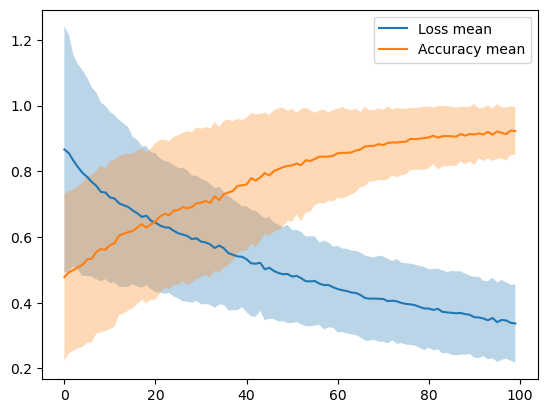

In [18]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean2, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)

plt.plot(epochs, acc_mean2, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()

Half dimension of the parameter' space, similar results

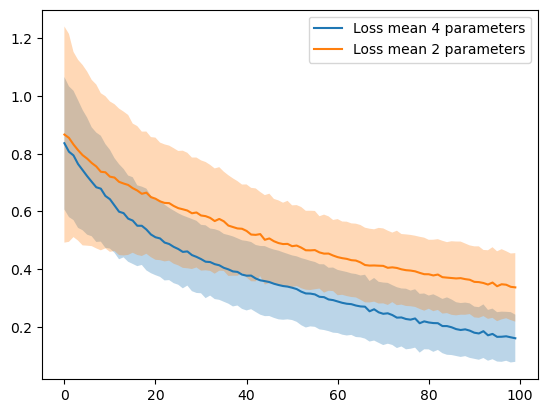

In [19]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean 4 parameters")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, loss_mean2, label="Loss mean 2 parameters")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)
plt.legend()
plt.show()

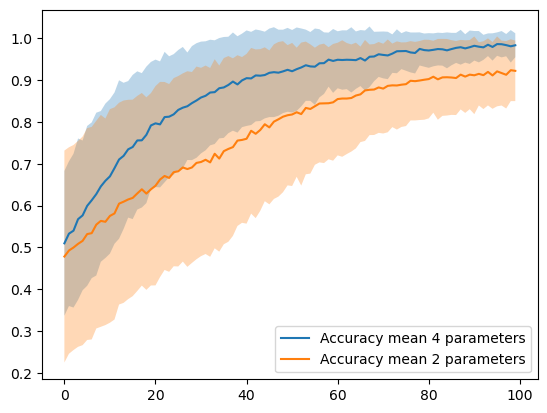

In [20]:
plt.plot(epochs, acc_mean1, label="Accuracy mean 4 parameters")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)
plt.plot(epochs, acc_mean2, label="Accuracy mean 2 parameters")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()